<a href="https://colab.research.google.com/github/s31302/wma/blob/main/Projekt_4_ostateczny_seed_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR-10

Instrukcje
Zaimplementuj, wytrenuj i przetestuj model sieci neuronowej do klasyfikacji obrazów z zestawu danych CIFAR-10. Zestaw danych składa się z 60 000 kolorowych obrazów (32×32 piksele) podzielonych na 10 klas, w tym samochody, psy, statki i inne.

Wytyczne dotyczące modelu:
- Użyj warstw Conv2D, Dropout, Dense, MaxPooling2D i Flatten.
- Jeśli sieć zawiera więcej niż 10 warstw, użyj kernel_initializer, aby poprawić wydajność i zapobiec problemowi zanikającego gradientu.

Kryteria oceny:
Wydajność Twojego modelu będzie oceniana na podstawie końcowej dokładności danych testowych:
- Dokładność < 0,599 → 0 punktów
- 0,600 < Dokładność < 0,699 → 7 punktów
- 0,700 < Dokładność > 0,779 → 9 punktów
- 0,78 < Dokładność > 0,799 → 12 punktów
- Dokładność > 0,800 → 14 punktów

Wymagane wyniki (do uwzględnienia w raporcie):
- Wizualizacja architektury sieciowej
- Wyeksportowany plik modelu (`.keras`)
- Macierz pomyłek
- Wykres historii uczenia (krzywe dokładności/strat)
- Końcowa dokładność danych testowych
- Kod źródłowy
Moja praca



In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test)=cifar10.load_data()

print('Shape of x_train is {}'.format(x_train.shape))
print('Shape of x_test is {}'.format(x_test.shape))
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Shape of x_train is (50000, 32, 32, 3)
Shape of x_test is (10000, 32, 32, 3)
Shape of y_train is (50000, 1)
Shape of y_test is (10000, 1)


 (50000, 32, 32, 3) -> Oznacza to 50 tysięcy obrazków, z których każdy ma 32x32 piksele, a każdy piksel ma 3 kolory (RGB).

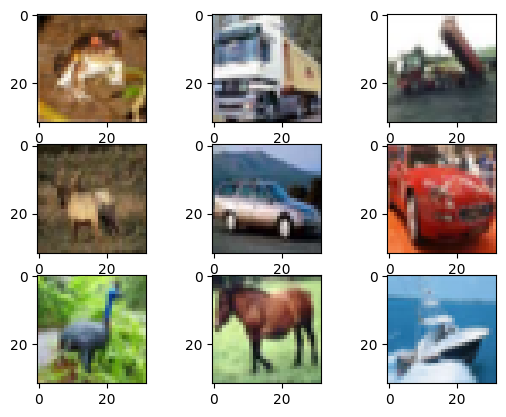

In [ ]:
from matplotlib import pyplot

for i in range(9):
	# define subplot
	pyplot.subplot(330 + 1 + i)
	# plot raw pixel data
	pyplot.imshow(x_train[i])
# show the figure
pyplot.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from matplotlib import pyplot

def load_dataset():
    # 1. Ładowanie danych
    (trainX, trainY), (testX, testY) = cifar10.load_data()

    # 2. One-hot encoding (zamiana etykiet 0-9 na wektory binarne)
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)

    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    # Konwersja na liczby zmiennoprzecinkowe i normalizacja do zakresu 0-1
    train_norm = train.astype('float32') / 255.0
    test_norm = test.astype('float32') / 255.0
    return train_norm, test_norm

# Wywołanie funkcji
x_train, y_train, x_test, y_test = load_dataset()
x_train, x_test = prep_pixels(x_train, x_test)

print(f'Shape of x_train: {x_train.shape}')
print('Shape of y_train is {}'.format(y_train.shape))


Shape of x_train: (50000, 32, 32, 3)
Shape of y_train is (50000, 10)


# SGD

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych

    # Optymalizacja
    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    #trenowanie
    history = model.fit(trainX, trainY, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

    #ocena
    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    # Zapisywanie modelu
    model.save('final_model.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.1400 - loss: 2.2660 - val_accuracy: 0.2343 - val_loss: 2.0828
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2500 - loss: 1.9821 - val_accuracy: 0.3485 - val_loss: 1.8005
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3107 - loss: 1.8234 - val_accuracy: 0.3732 - val_loss: 1.6912
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3488 - loss: 1.7325 - val_accuracy: 0.4205 - val_loss: 1.5713
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3833 - loss: 1.6522 - val_accuracy: 0.4331 - val_loss: 1.5821
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4089 - loss: 1.5870 - val_accuracy: 0.4566 - val_loss: 1.4886
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4327 - loss: 1.5260 - val_accuracy: 0.4787 - val_loss: 1.4403
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4517 - loss: 1.4858 - val_ac

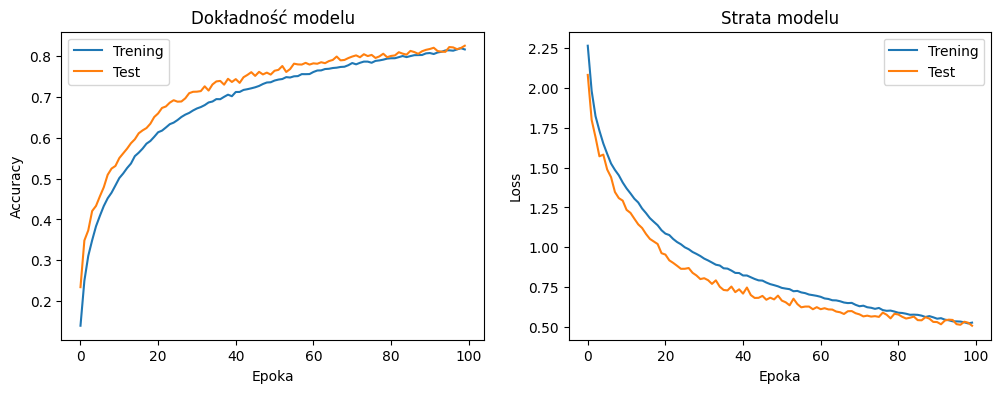

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 1000x800 with 0 Axes>

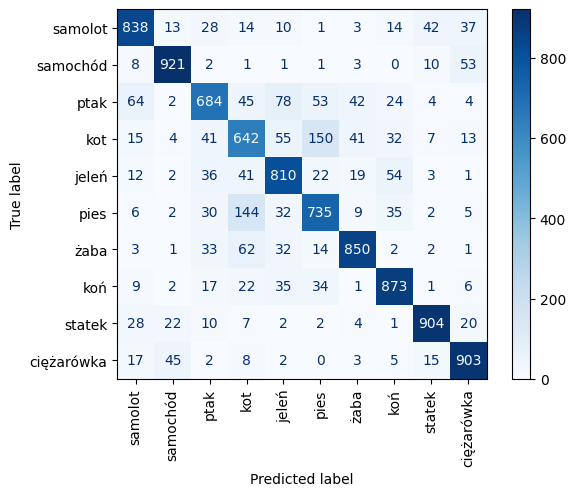

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

# Adam

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych

    #Adam optymalizacja
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    history = model.fit(trainX, trainY, epochs=100, batch_size=64, validation_split=0.2, verbose=1)

    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    model.save('final_model_adam.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.3049 - loss: 1.8641 - val_accuracy: 0.4804 - val_loss: 1.3967
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4931 - loss: 1.3959 - val_accuracy: 0.5728 - val_loss: 1.1723
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5782 - loss: 1.1918 - val_accuracy: 0.6513 - val_loss: 0.9811
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6302 - loss: 1.0572 - val_accuracy: 0.6814 - val_loss: 0.8860
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6630 - loss: 0.9713 - val_accuracy: 0.6992 - val_loss: 0.8409
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6856 - loss: 0.9045 - val_accuracy: 0.7284 - val_loss: 0.7693
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7041 - loss: 0.8612 - val_accuracy: 0.7309 - val_loss: 0.7748
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7201 - loss: 0.8132 - val_ac

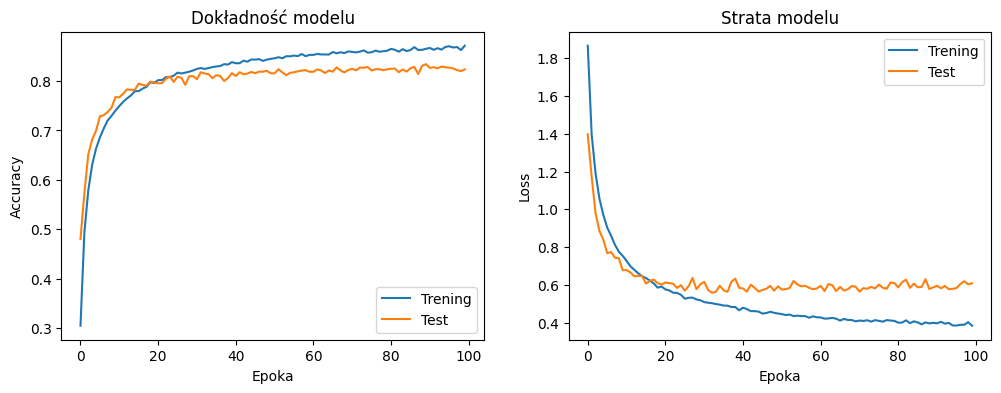

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Figure size 1000x800 with 0 Axes>

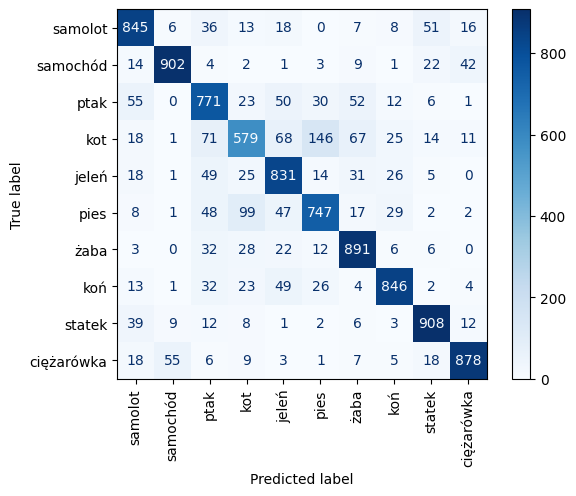

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,651,712 (6.30 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,101,142 (4.20 MB)

# Adam + argumentacja

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych

    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()
    # argumentaacja z przesuwaniem i filpem
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
    it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
    it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
    steps = int((trainX.shape[0] * 0.8) / 64)
    val_steps = int((trainX.shape[0] * 0.2) / 64)

    history = model.fit(it_train, steps_per_epoch=steps, epochs=100, batch_size=64, validation_data=it_val, validation_steps=val_steps, verbose=1)

    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    model.save('final_model_argumentacja.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.2915 - loss: 1.8878 - val_accuracy: 0.4356 - val_loss: 1.5287
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.4395 - loss: 1.5281 - val_accuracy: 0.5262 - val_loss: 1.2931
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5061 - loss: 1.3659 - val_accuracy: 0.5917 - val_loss: 1.1387
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.5619 - loss: 1.2341 - val_accuracy: 0.6169 - val_loss: 1.0684
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.5982 - loss: 1.1423 - val_accuracy: 0.6341 - val_loss: 1.0301
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.6192 - loss: 1.0876 - val_accuracy: 0.6565 - val_loss: 0.9536
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6451 - loss: 1.0254 - val_accuracy: 0.6990 - val_loss: 0.8599
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.6598 - loss: 0

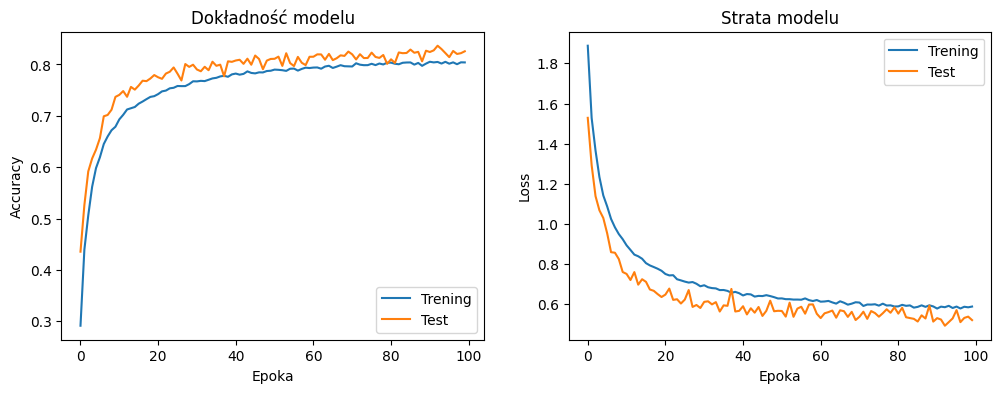

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Figure size 1000x800 with 0 Axes>

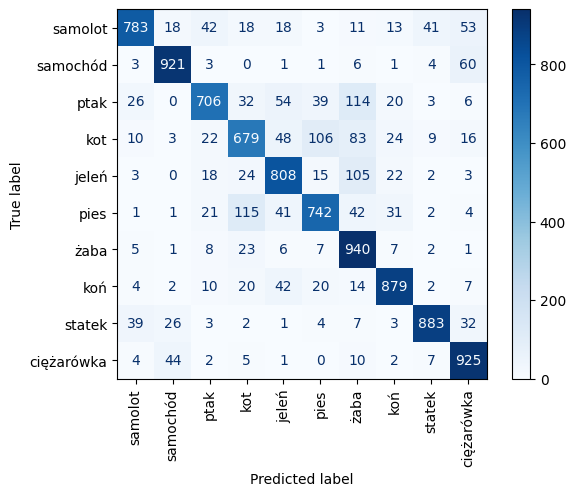

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,651,712 (6.30 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,101,142 (4.20 MB)

# SGD + argumentacja

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def define_model():
    model = Sequential()

    init = 'he_uniform'

    # Blok 1
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same', input_shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.2)) # Zapobieganie overfittingowi

    # Blok 2
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(64, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.3))

    # Blok 3
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', kernel_initializer=init, padding='same'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    # Klasyfikator
    model.add(Flatten())
    model.add(Dense(128, activation='relu', kernel_initializer=init))
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax')) # 10 klas wyjściowych


    opt = SGD(learning_rate=0.001, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

def run_test_harness():
    trainX, trainY, testX, testY = load_dataset()
    trainX, testX = prep_pixels(trainX, testX)

    model = define_model()

    #argumentacja
    datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
    it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
    it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
    steps = int((trainX.shape[0] * 0.8) / 64)
    val_steps = int((trainX.shape[0] * 0.2) / 64)

    history = model.fit(it_train, steps_per_epoch=steps, epochs=100, batch_size=64, validation_data=it_val, validation_steps=val_steps, verbose=1)

    _, acc = model.evaluate(testX, testY, verbose=0)
    print(f'> Finalna dokładność: {acc:.3f}')

    model.save('final_model_sgd_argumentacja.keras')

    return model, history, testX, testY

# Wywołanie
model, history, testX, testY = run_test_harness()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.1620 - loss: 2.2096 - val_accuracy: 0.2413 - val_loss: 2.0381
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.2489 - loss: 1.9849 - val_accuracy: 0.3130 - val_loss: 1.8383
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.3061 - loss: 1.8476 - val_accuracy: 0.3718 - val_loss: 1.7203
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.3381 - loss: 1.7634 - val_accuracy: 0.3905 - val_loss: 1.6340
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 51ms/step - accuracy: 0.3658 - loss: 1.6984 - val_accuracy: 0.4092 - val_loss: 1.6007
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.3823 - loss: 1.6516 - val_accuracy: 0.4420 - val_loss: 1.5148
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.4023 - loss: 1.6047 - val_accuracy: 0.4542 - val_loss: 1.4880
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.4171 - loss: 1

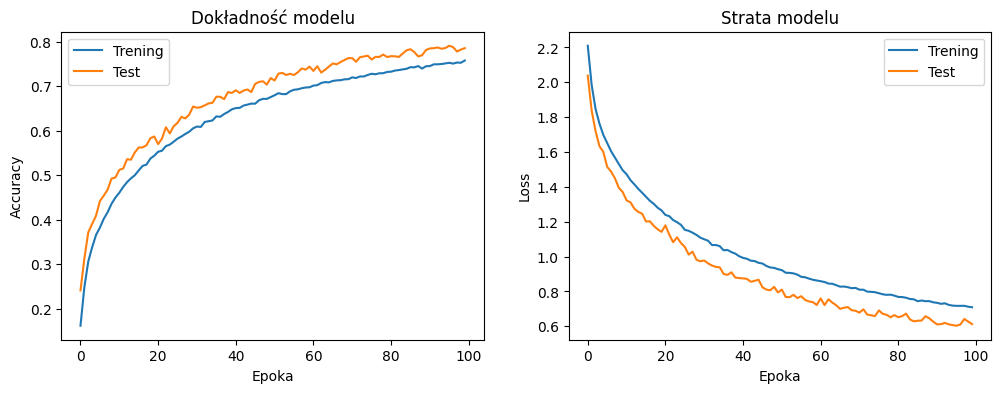

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Figure size 1000x800 with 0 Axes>

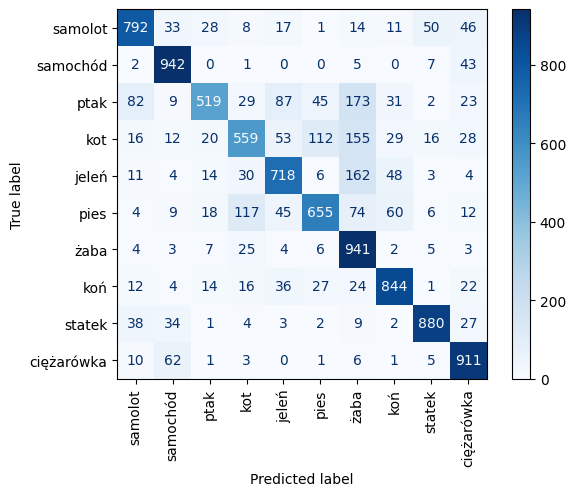

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

# SGD + argumentacja dalsze 200 epok

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator # DODANE: import generatora

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
steps = int((trainX.shape[0] * 0.8) / 64)
val_steps = int((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('final_model_sgd_argumentacja.keras')

# ZMIENIONE: Użycie generatora (it_train) i kroków (steps_per_epoch) zamiast surowych tablic trainX i trainY
history = model.fit(
    it_train,
    steps_per_epoch=steps,
    epochs=200,
    initial_epoch=100,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1
)


model.save('final_model_sgd_argumentacja_200epok.keras')

_, acc = model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

Epoch 101/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.7585 - loss: 0.7065 - val_accuracy: 0.7922 - val_loss: 0.5913
Epoch 102/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7587 - loss: 0.7031 - val_accuracy: 0.7841 - val_loss: 0.6124
Epoch 103/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.7586 - loss: 0.7022 - val_accuracy: 0.7918 - val_loss: 0.6011
Epoch 104/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.7594 - loss: 0.7035 - val_accuracy: 0.7902 - val_loss: 0.6012
Epoch 105/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7614 - loss: 0.6941 - val_accuracy: 0.7866 - val_loss: 0.6021
Epoch 106/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.7647 - loss: 0.6907 - val_accuracy: 0.7939 - val_loss: 0.5930
Epoch 107/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7633 - loss: 0.6885 - val_accuracy: 0.7900 - val_loss: 0.5949
Epoch 108/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 

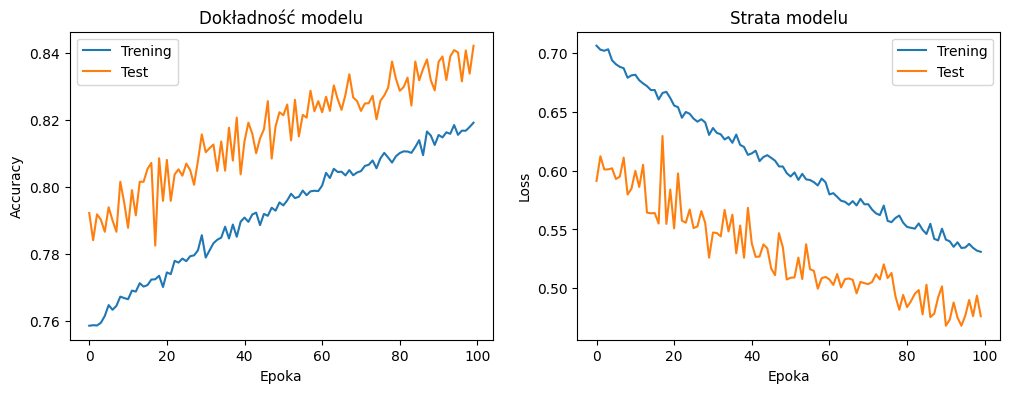

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


<Figure size 1000x800 with 0 Axes>

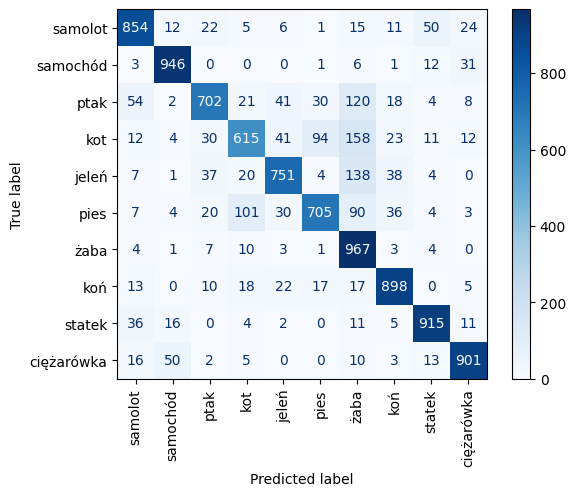

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,101,142 (4.20 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 550,572 (2.10 MB)

# Adam + argumentacja dalsze 200 epok

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator # DODANE: import generatora

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)
steps = int((trainX.shape[0] * 0.8) / 64)
val_steps = int((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('final_model_argumentacja.keras')

history = model.fit(
    it_train,
    steps_per_epoch=steps,
    epochs=200,
    initial_epoch=100,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1
)

model.save('final_model_argumentacja_200epok.keras')

Epoch 101/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 301s 470ms/step - accuracy: 0.7880 - loss: 0.6377 - val_accuracy: 0.8407 - val_loss: 0.4546
Epoch 102/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 516ms/step - accuracy: 0.7907 - loss: 0.6288 - val_accuracy: 0.8366 - val_loss: 0.4798
Epoch 103/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 516ms/step - accuracy: 0.7890 - loss: 0.6305 - val_accuracy: 0.8431 - val_loss: 0.4636
Epoch 104/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.7915 - loss: 0.6228 - val_accuracy: 0.8450 - val_loss: 0.4483
Epoch 105/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 323s 471ms/step - accuracy: 0.7911 - loss: 0.6235 - val_accuracy: 0.8443 - val_loss: 0.4660
Epoch 106/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.7911 - loss: 0.6249 - val_accuracy: 0.8376 - val_loss: 0.4665
Epoch 107/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 323s 471ms/step - accuracy: 0.7934 - loss: 0.6174 - val_accuracy: 0.8388 - val_loss: 0.4738
Epoch 108/200
625/625 ━━━━━━━━━━━━━━━━━━━━ 322s 515ms/s

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

# SGD + argumentacja >200 epok

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # DODANE: import callbacków
import math # DODANE: import math dla ceil

def prep_pixels(train, test):
    return train.astype('float32') / 255.0, test.astype('float32') / 255.0

def load_dataset():
    (trainX, trainY), (testX, testY) = cifar10.load_data()
    trainY = to_categorical(trainY)
    testY = to_categorical(testY)
    return trainX, trainY, testX, testY

trainX, trainY, testX, testY = load_dataset()
trainX, testX = prep_pixels(trainX, testX)

datagen = ImageDataGenerator(width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True, validation_split=0.2)
it_train = datagen.flow(trainX, trainY, batch_size=64, subset='training', seed=42)
it_val = datagen.flow(trainX, trainY, batch_size=64, subset='validation', seed=42)

steps_per_epoch = math.ceil((trainX.shape[0] * 0.8) / 64)
val_steps = math.ceil((trainX.shape[0] * 0.2) / 64)

model = tf.keras.models.load_model('final_model_sgd_argumentacja_200epok.keras')

es = EarlyStopping(monitor='val_accuracy', mode='max', patience=20, verbose=1)
mc = ModelCheckpoint('final_model_sgd_argumentacja_extended_best.keras', monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

history = model.fit(
    it_train,
    steps_per_epoch=steps_per_epoch,
    epochs=300,
    initial_epoch=200,
    validation_data=it_val, validation_steps=val_steps,
    verbose=1,
    callbacks=[es, mc] # DODANE: Callbacki do treningu
)

# Wczytanie najlepszego zapisanego modelu do oceny
saved_model = tf.keras.models.load_model('final_model_sgd_argumentacja_extended_best.keras')

_, acc = saved_model.evaluate(testX, testY, verbose=0)
print(f'> Finalna dokładność najlepszego modelu po kontynuacji: {acc:.3f}')

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

In [ ]:
y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
model.summary()

In [ ]:
import pydot
import graphviz

!pip install pydot
!apt-get install graphviz -y

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
model.save('/content/drive/MyDrive/Modele/final_model.keras')
model.save('/content/drive/MyDrive/Modele/final_model2.keras')
model.save('/content/drive/MyDrive/Modele/final_model_argumentacja.keras')
model.save('/content/drive/MyDrive/Modele/final_model_sgd_argumentacja.keras')
model.save('/content/drive/MyDrive/Modele/final_model_sgd_argumentacja_200epok.keras')
model.save('/content/drive/MyDrive/Modele/final_model_argumentacja_200epok.keras')
model.save('/content/drive/MyDrive/Modele/final_model_sgd_argumentacja_extended_best.keras')




# Podsumowanie

SGD:
100 -> accuracy: 0.8286 - loss: 0.4934 - val_accuracy: 0.8280 - val_loss: 0.5169
+ argumentacja 100 -> accuracy: 0.7031 - loss: 0.8191 - val_accuracy: 0.7350 - val_loss: 0.7626
+ argumentacja 200 ->  accuracy: 0.8281 - loss: 0.4688 - val_accuracy: 0.8102 - val_loss: 0.5557
+ argumentacja > 200 -> accuracy: 0.8015 - loss: 0.5959 - val_accuracy: 0.8383 - val_loss: 0.5010

Adam:
100 ->  accuracy: 0.8532 - loss: 0.4275 - val_accuracy: 0.8123 - val_loss: 0.6793
+ argumentacja 100 -> accuracy: 0.7500 - loss: 0.7067 - val_accuracy: 0.8054 - val_loss: 0.6092
+ argumentacja 200 -> accuracy: 0.7656 - loss: 0.5910 - val_accuracy: 0.8213 - val_loss: 0.5638

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('final_model_sgd_argumentacja_extended_best.keras')


tf.keras.utils.plot_model(model, to_file='architektura.png', show_shapes=True, show_layer_names=True)



In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model('final_model_sgd_argumentacja_extended_best.keras')

y_pred = model.predict(testX)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(testY, axis=1)

classes = ['samolot', 'samochód', 'ptak', 'kot', 'jeleń', 'pies', 'żaba', 'koń', 'statek', 'ciężarówka']

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical')
plt.show()

In [ ]:
#epoki od 200
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Wykres dokładności
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Trening')
    plt.plot(history.history['val_accuracy'], label='Test')
    plt.title('Dokładność modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()

    # Wykres straty
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Trening')
    plt.plot(history.history['val_loss'], label='Test')
    plt.title('Strata modelu')
    plt.xlabel('Epoka')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)